**This code is to generate multi-class masks from yolo_labels**

In [1]:
# Import libraries
import os
import yaml
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

In [2]:
subset = 'train'

# Paths
dataset_path = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v5/"
yaml_file = os.path.join(dataset_path, 'data.yaml') # "/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/data.yaml"
images_dir = os.path.join(dataset_path, subset, 'aug_images') # r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/images"
yolo_labels_dir = os.path.join(dataset_path, subset, 'aug_labels') # r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/labels"
masks_dir = os.path.join(dataset_path, subset, 'aug_masks')

In [3]:
images = os.listdir(images_dir)
yolo_labels = os.listdir(yolo_labels_dir)

# Load class names from YAML
with open(yaml_file, "r") as f:
    data = yaml.safe_load(f)
class_names = data["names"]
print("class names:", class_names)

class names: ['abdomen', 'head', 'thorax']


In [4]:
images = os.listdir(images_dir)
image_path = os.path.join(images_dir, images[0])
image_path, os.path.basename(image_path), os.path.basename(image_path)[:-4]+"_m.jpg"

('/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v5/train/aug_images/Bombus_distinguendus_GBIF_iNat_2573822774_2-jpg_jpg.rf.554f43a33c372472a2c1c17d493deb1c_flip_v.jpg',
 'Bombus_distinguendus_GBIF_iNat_2573822774_2-jpg_jpg.rf.554f43a33c372472a2c1c17d493deb1c_flip_v.jpg',
 'Bombus_distinguendus_GBIF_iNat_2573822774_2-jpg_jpg.rf.554f43a33c372472a2c1c17d493deb1c_flip_v_m.jpg')

In [5]:
# Get mask path from a given image path
# def get_mask_path(image_path):
#     mask_path = image_path.replace("images", "masks")
#     mask_path = os.path.splitext(mask_path)[0] + "_m.png"
#     return mask_path

# Get mask from yolo annotation
def yolo_polygon_to_mask(image_path, label_path, mask_dir):
    """
    Faster YOLO polygon → mask conversion
    """
    os.makedirs(mask_dir, exist_ok=True)
    mask_name = os.path.splitext(os.path.basename(image_path))[0] + "_m.png"
    mask_path = os.path.join(mask_dir, mask_name)

    # Get image size WITHOUT decoding pixels
    with Image.open(image_path) as img:
        iw, ih = img.size

    # Initialize mask
    mask = np.zeros((ih, iw), dtype=np.uint8)

    if not os.path.exists(label_path):
        cv2.imwrite(mask_path, mask)
        return

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 7:
                continue

            cls = int(float(parts[0]))
            coords = np.array(parts[1:], dtype=np.float32).reshape(-1, 2)

            # Vectorized normalized → pixel conversion
            coords[:, 0] *= iw
            coords[:, 1] *= ih

            poly = coords.astype(np.int32)

            # OpenCV fill (VERY fast)
            cv2.fillPoly(mask, [poly], cls + 1)

    cv2.imwrite(mask_path, mask)

def visualize_mask(image_path, mask_path, alpha=0.5):
    """
    Visualize segmentation mask overlaid on image.
    - image_path: path to RGB image
    - mask_path: path to mask (grayscale, class indices)
    - alpha: transparency of mask overlay
    """
    # Load image
    img = Image.open(image_path).convert("RGB")
    img = np.array(img)

    # Load mask
    mask = Image.open(mask_path)
    mask = np.array(mask)

    # Define a color map (class 0=background, others get unique colors)
    num_classes = mask.max() + 1
    cmap = plt.cm.get_cmap("tab20", num_classes)  # 20 distinct colors

    # Create RGB mask
    mask_rgb = cmap(mask)[:, :, :3]  # ignore alpha channel
    mask_rgb = (mask_rgb * 255).astype(np.uint8)

    # Blend image and mask
    overlay = (alpha * mask_rgb + (1 - alpha) * img).astype(np.uint8)

    # Plot side by side
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(img)
    axs[0].set_title("Original Image")
    axs[0].axis("off")

    axs[1].imshow(mask, cmap="nipy_spectral")
    axs[1].set_title("Mask (class indices)")
    axs[1].axis("off")

    axs[2].imshow(overlay)
    axs[2].set_title("Overlay")
    axs[2].axis("off")

    plt.tight_layout()
    plt.show()

Generating masks from training images

In [6]:
subset = 'train'
images_dir = os.path.join(dataset_path, subset, 'images')
yolo_labels_dir = os.path.join(dataset_path, subset, 'labels') # r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/labels"
masks_dir = os.path.join(dataset_path, subset, 'masks')
image_files = os.listdir(images_dir)

for image_file in tqdm(image_files):
    label_file = os.path.splitext(image_file)[0] + ".txt"
    image_path = os.path.join(images_dir, image_file)
    label_path = os.path.join(yolo_labels_dir, label_file)
    yolo_polygon_to_mask(image_path=image_path, label_path=label_path, mask_dir=masks_dir)

100%|██████████| 5787/5787 [04:07<00:00, 23.38it/s]


Generating masks for augmented training images

In [6]:
subset = 'train'
image_dir = os.path.join(dataset_path, subset, 'aug_images')
yolo_labels_dir = os.path.join(dataset_path, subset, 'aug_labels') # r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/labels"
mask_dir = os.path.join(dataset_path, subset, 'aug_masks')
image_files = os.listdir(image_dir)

for image_file in tqdm(image_files):
    label_file = os.path.splitext(image_file)[0] + ".txt"
    image_path = os.path.join(image_dir, image_file)
    label_path = os.path.join(yolo_labels_dir, label_file)
    yolo_polygon_to_mask(image_path=image_path, label_path=label_path, mask_dir=mask_dir)

100%|██████████| 34722/34722 [34:54<00:00, 16.58it/s]  


Generating masks for validation images

In [18]:
subset = 'valid'

# Paths
dataset_path = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/"
images_dir = os.path.join(dataset_path, subset, 'images') # r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/images"
yolo_labels_dir = os.path.join(dataset_path, subset, 'fixed_labels') # r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/labels"
masks_dir = os.path.join(dataset_path, subset, 'masks')

image_files = os.listdir(images_dir)

for image_file in tqdm(image_files):
    label_file = os.path.splitext(image_file)[0] + ".txt"
    image_path = os.path.join(images_dir, image_file)
    label_path = os.path.join(yolo_labels_dir, label_file)
    yolo_polygon_to_mask(image_path=image_path, label_path=label_path, mask_dir=masks_dir)

100%|██████████| 1158/1158 [00:04<00:00, 256.33it/s]


Generating masks for test images

In [19]:
subset = 'test'

# Paths
dataset_path = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/"
images_dir = os.path.join(dataset_path, subset, 'images') # r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/images"
yolo_labels_dir = os.path.join(dataset_path, subset, 'fixed_labels') # r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/labels"
masks_dir = os.path.join(dataset_path, subset, 'masks')

image_files = os.listdir(images_dir)

for image_file in tqdm(image_files):
    label_file = os.path.splitext(image_file)[0] + ".txt"
    image_path = os.path.join(images_dir, image_file)
    label_path = os.path.join(yolo_labels_dir, label_file)
    yolo_polygon_to_mask(image_path=image_path, label_path=label_path, mask_dir=masks_dir)

100%|██████████| 771/771 [00:02<00:00, 257.67it/s]


/tmp/ipykernel_2408104/2626225358.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_classes)  # 20 distinct colors


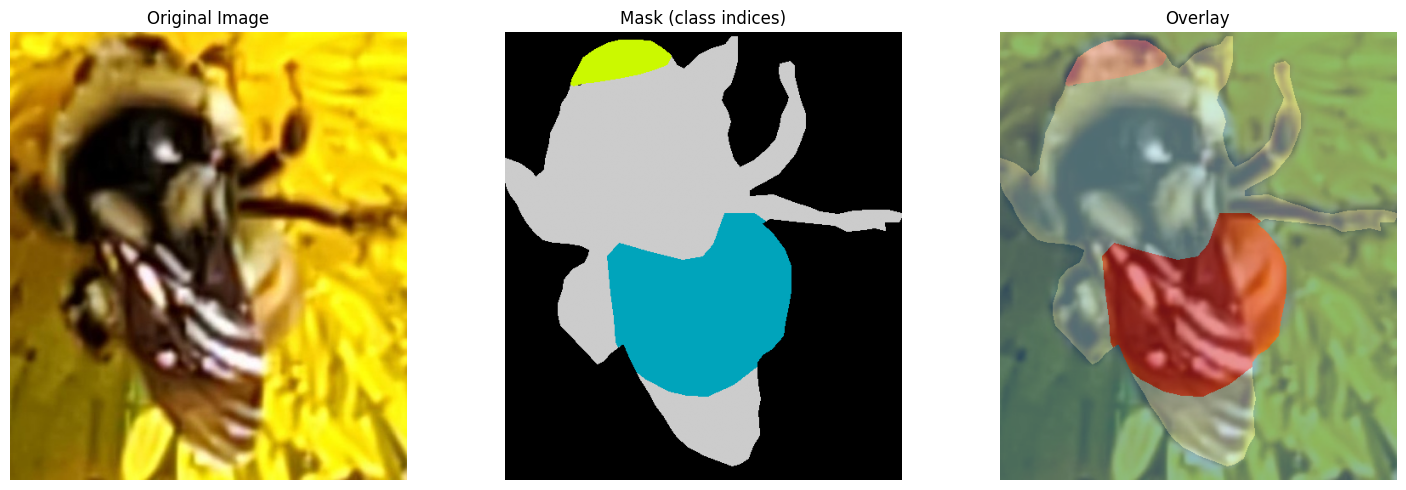

In [20]:
# Visualize sample mask
dataset_path = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/"
image_dir = os.path.join(dataset_path, 'train', 'aug_images')
image_files = os.listdir(image_dir)
image_file = image_files[1] # Random image file
image_path = os.path.join(image_dir, image_file)
mask_path = image_path.replace("aug_images", "aug_masks")
mask_path = os.path.splitext(mask_path)[0] + "_m.png"
visualize_mask(image_path, mask_path)

/tmp/ipykernel_2408104/2626225358.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_classes)  # 20 distinct colors


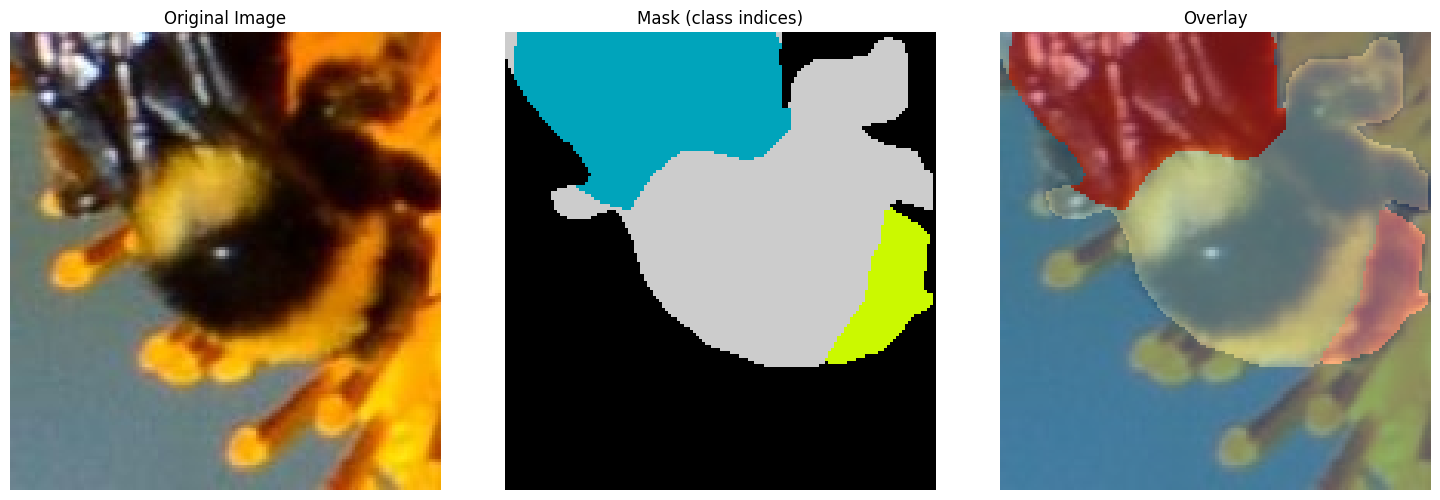

In [21]:
# Visualize sample mask
dataset_path = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/"
image_dir = os.path.join(dataset_path, 'train', 'aug_images')
image_files = os.listdir(image_dir)
image_file = image_files[8] # Random image file
image_path = os.path.join(image_dir, image_file)
mask_path = image_path.replace("aug_images", "aug_masks")
mask_path = os.path.splitext(mask_path)[0] + "_m.png"
visualize_mask(image_path, mask_path)

/tmp/ipykernel_2408104/2626225358.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_classes)  # 20 distinct colors


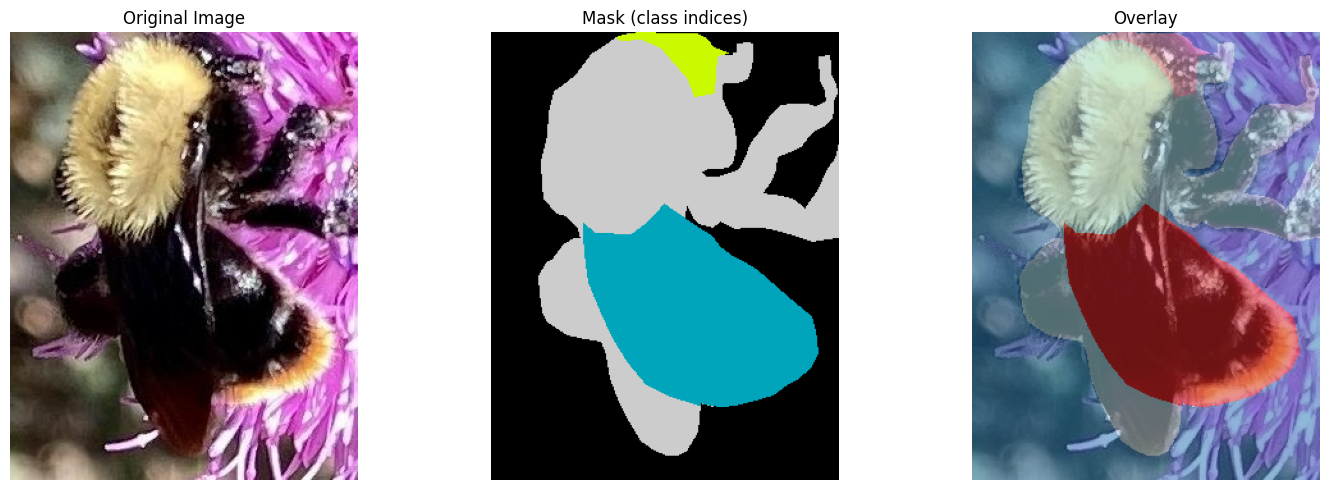

In [22]:
# Visualize sample mask
dataset_path = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/"
image_dir = os.path.join(dataset_path, 'train', 'aug_images')
image_files = os.listdir(image_dir)
image_file = image_files[66] # Random image file
image_path = os.path.join(image_dir, image_file)
mask_path = image_path.replace("aug_images", "aug_masks")
mask_path = os.path.splitext(mask_path)[0] + "_m.png"
visualize_mask(image_path, mask_path)

/tmp/ipykernel_2408104/2626225358.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_classes)  # 20 distinct colors


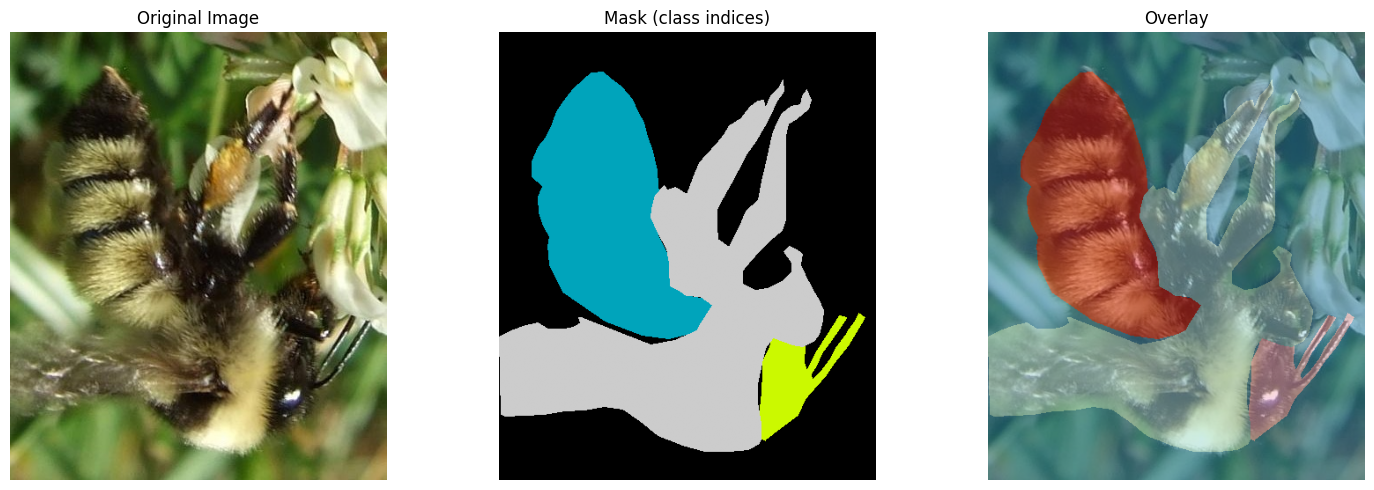

In [23]:
# Visualize sample mask
dataset_path = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/"
image_dir = os.path.join(dataset_path, 'train', 'aug_images')
image_files = os.listdir(image_dir)
image_file = image_files[3] # Random image file
image_path = os.path.join(image_dir, image_file)
mask_path = image_path.replace("aug_images", "aug_masks")
mask_path = os.path.splitext(mask_path)[0] + "_m.png"
visualize_mask(image_path, mask_path)

/tmp/ipykernel_2408104/2626225358.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_classes)  # 20 distinct colors


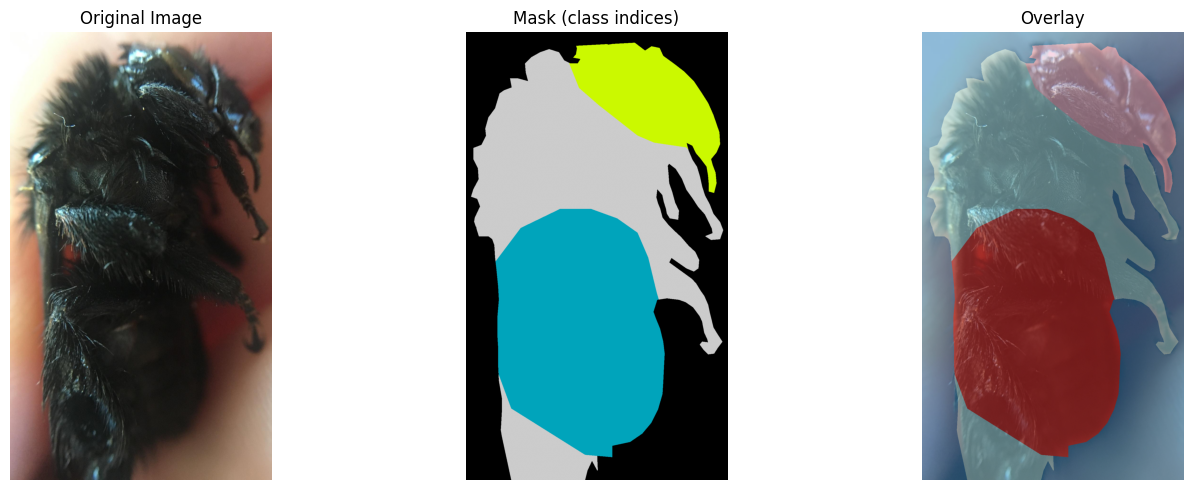

In [25]:
# Visualize sample mask
dataset_path = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/"
image_dir = os.path.join(dataset_path, 'valid', 'images')
image_files = os.listdir(image_dir)
image_file = image_files[3] # Random image file
image_path = os.path.join(image_dir, image_file)
mask_path = image_path.replace("images", "masks")
mask_path = os.path.splitext(mask_path)[0] + "_m.png"
visualize_mask(image_path, mask_path)

/tmp/ipykernel_2408104/2626225358.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_classes)  # 20 distinct colors


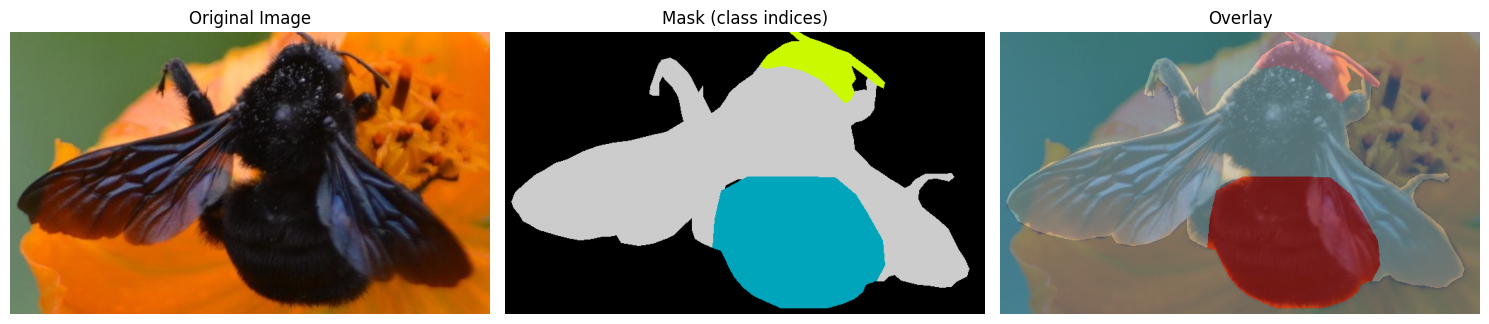

In [26]:
# Visualize sample mask
dataset_path = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/"
image_dir = os.path.join(dataset_path, 'valid', 'images')
image_files = os.listdir(image_dir)
image_file = image_files[366] # Random image file
image_path = os.path.join(image_dir, image_file)
mask_path = image_path.replace("images", "masks")
mask_path = os.path.splitext(mask_path)[0] + "_m.png"
visualize_mask(image_path, mask_path)

/tmp/ipykernel_2408104/2626225358.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_classes)  # 20 distinct colors


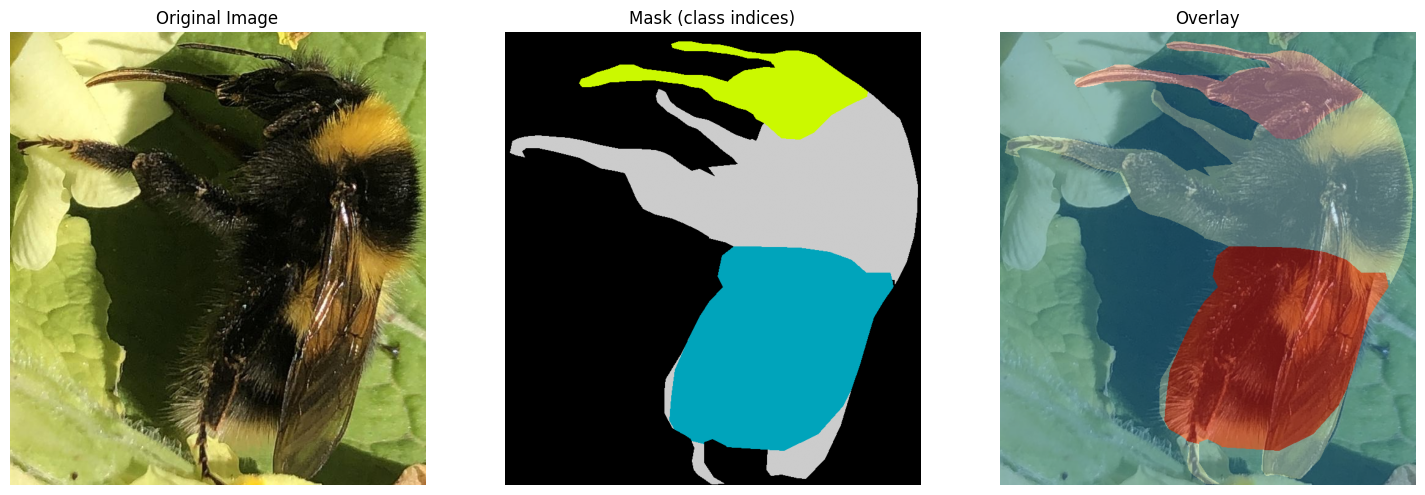

In [27]:
# Visualize sample mask
dataset_path = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/"
image_dir = os.path.join(dataset_path, 'test', 'images')
image_files = os.listdir(image_dir)
image_file = image_files[366] # Random image file
image_path = os.path.join(image_dir, image_file)
mask_path = image_path.replace("images", "masks")
mask_path = os.path.splitext(mask_path)[0] + "_m.png"
visualize_mask(image_path, mask_path)

/tmp/ipykernel_2408104/2626225358.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_classes)  # 20 distinct colors


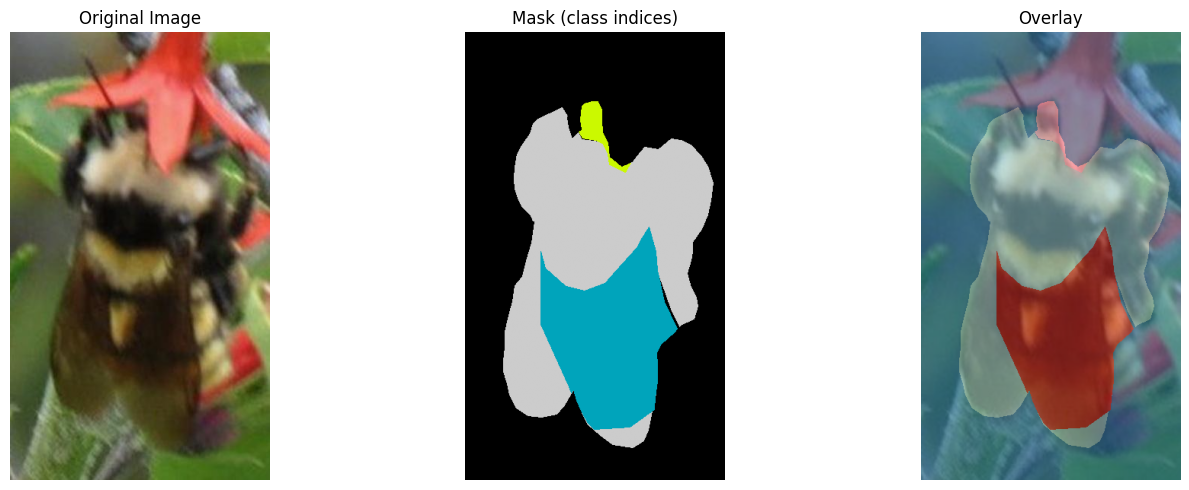

In [28]:
# Visualize sample mask
dataset_path = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/"
image_dir = os.path.join(dataset_path, 'test', 'images')
image_files = os.listdir(image_dir)
image_file = image_files[3] # Random image file
image_path = os.path.join(image_dir, image_file)
mask_path = image_path.replace("images", "masks")
mask_path = os.path.splitext(mask_path)[0] + "_m.png"
visualize_mask(image_path, mask_path)

/tmp/ipykernel_2408104/2626225358.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_classes)  # 20 distinct colors


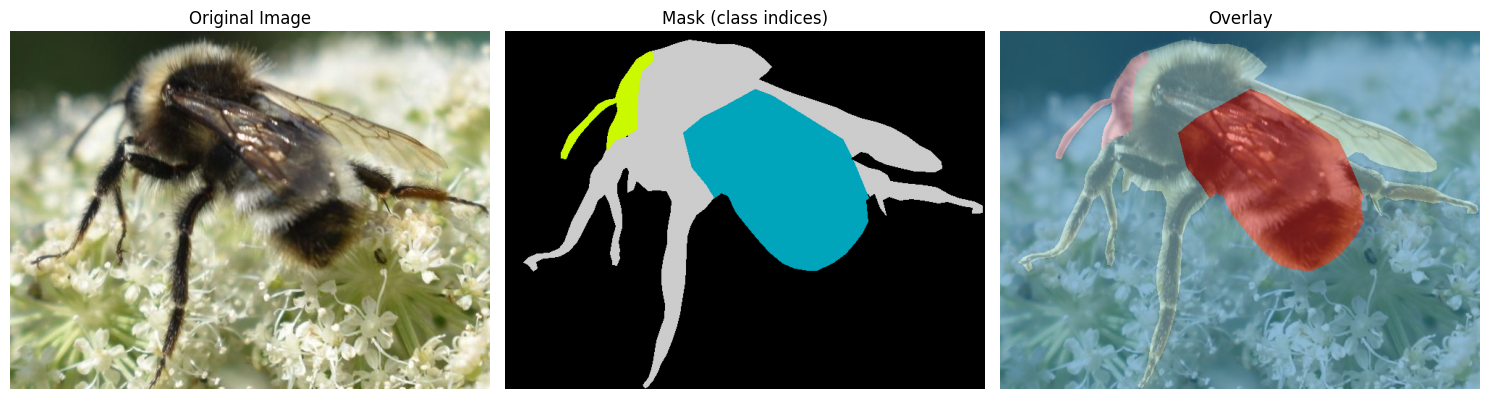

In [29]:
# Visualize sample mask
dataset_path = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/"
image_dir = os.path.join(dataset_path, 'test', 'images')
image_files = os.listdir(image_dir)
image_file = image_files[38] # Random image file
image_path = os.path.join(image_dir, image_file)
mask_path = image_path.replace("images", "masks")
mask_path = os.path.splitext(mask_path)[0] + "_m.png"
visualize_mask(image_path, mask_path)